In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df.shape

(891, 15)

In [6]:
df_cleaned = df

In [7]:
df_cleaned.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
# Out of 891 688 values are null for deck so we drop this column
df_cleaned.drop(['deck','who','adult_male','embark_town','alive'],axis=1,inplace=True)
df_cleaned.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,False
1,1,1,female,38.0,1,0,71.2833,C,First,False
2,1,3,female,26.0,0,0,7.9250,S,Third,True
3,1,1,female,35.0,1,0,53.1000,S,First,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True


<Axes: >

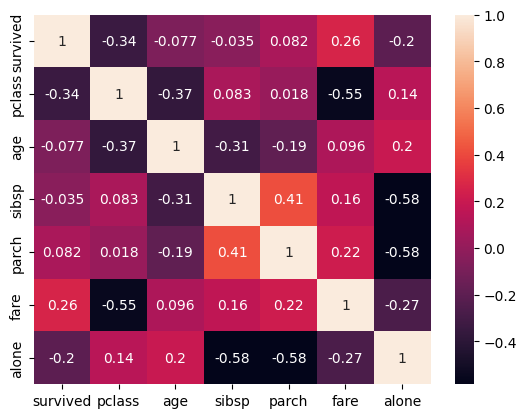

In [9]:
sns.heatmap(df_cleaned.corr(numeric_only=True),annot=True)

<Axes: xlabel='survived', ylabel='count'>

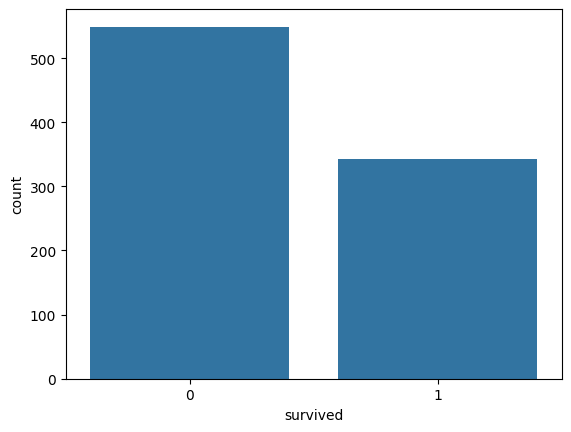

In [10]:
sns.countplot(x=df['survived'])

In [11]:
df_cleaned['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='count'>

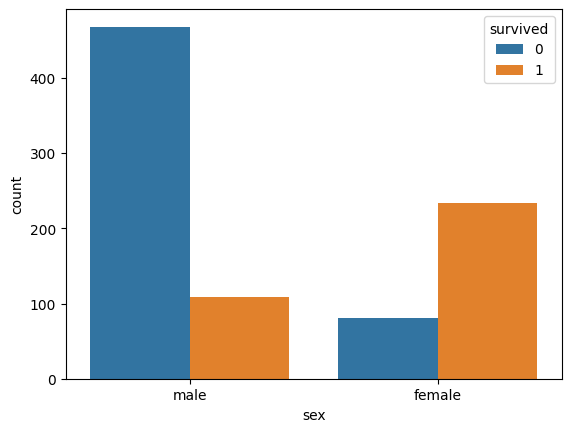

In [12]:
sns.countplot(x=df_cleaned['sex'],hue=df_cleaned['survived'])

<Axes: xlabel='embarked', ylabel='count'>

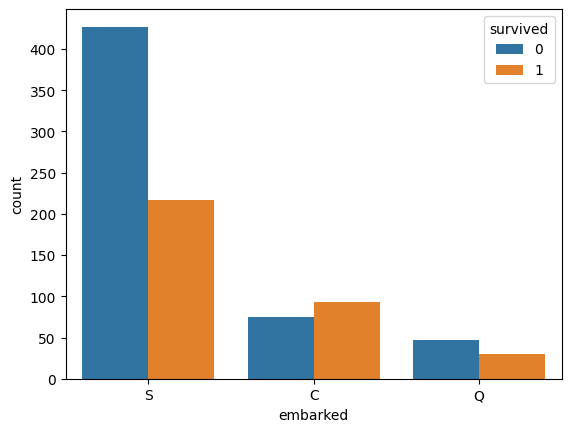

In [13]:
df_cleaned['embarked'].value_counts()
sns.countplot(x=df_cleaned['embarked'],hue=df_cleaned['survived'])

<Axes: xlabel='class', ylabel='count'>

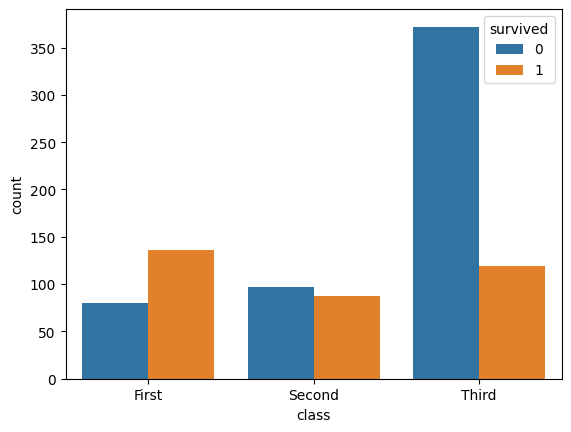

In [14]:
sns.countplot(x=df_cleaned['class'],hue=df_cleaned['survived'])

<Axes: xlabel='alone', ylabel='count'>

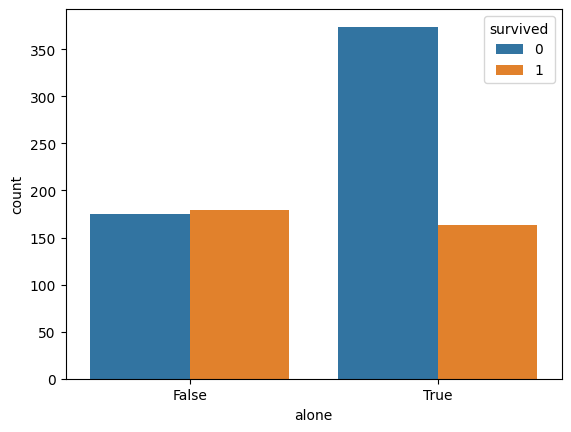

In [15]:
sns.countplot(x=df_cleaned['alone'],hue=df_cleaned['survived'])

In [16]:
# Handle missing values
df_cleaned['age'] = df_cleaned['age'].fillna(df_cleaned['age'].mean())


In [17]:
df_cleaned.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,False
1,1,1,female,38.0,1,0,71.2833,C,First,False
2,1,3,female,26.0,0,0,7.9250,S,Third,True
3,1,1,female,35.0,1,0,53.1000,S,First,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True


In [18]:
df_cleaned['embarked'] = df_cleaned['embarked'].fillna(df_cleaned['embarked'].mode()[0])
df_cleaned.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,False
1,1,1,female,38.0,1,0,71.2833,C,First,False
2,1,3,female,26.0,0,0,7.9250,S,Third,True
3,1,1,female,35.0,1,0,53.1000,S,First,False
4,0,3,male,35.0,0,0,8.0500,S,Third,True


In [19]:
df_cleaned.isnull().sum()

survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
class       0
alone       0
dtype: int64

In [20]:
df_encode = pd.get_dummies(df_cleaned)

In [21]:
df_encode.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third
0,0,3,22.0,1,0,7.2500,False,False,True,False,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,False,True,False,True,False,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,True,False,False,False,True,False,False,True
3,1,1,35.0,1,0,53.1000,False,True,False,False,False,True,True,False,False
4,0,3,35.0,0,0,8.0500,True,False,True,False,False,True,False,False,True


In [22]:
df_encode = df_encode.astype(int)

In [23]:
df_encode.head()

,survived,pclass,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third
0,0,3,22,1,0,7,0,0,1,0,0,1,0,0,1
1,1,1,38,1,0,71,0,1,0,1,0,0,1,0,0
2,1,3,26,0,0,7,1,1,0,0,0,1,0,0,1
3,1,1,35,1,0,53,0,1,0,0,0,1,1,0,0
4,0,3,35,0,0,8,1,0,1,0,0,1,0,0,1


In [24]:
pearson_corr_alive = df_encode.corr(method='pearson')['survived'].sort_values(ascending=False)
print(pearson_corr_alive)

survived        1.000000
sex_female      0.543351
class_First     0.285904
fare            0.257482
embarked_C      0.168240
class_Second    0.093349
parch           0.081629
embarked_Q      0.003650
sibsp          -0.035322
age            -0.067809
embarked_S     -0.149683
alone          -0.203367
class_Third    -0.322308
pclass         -0.338481
sex_male       -0.543351
Name: survived, dtype: float64


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
X=df_encode.drop("survived",axis=1)
y=df_encode["survived"]

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
model=GaussianNB()

In [44]:
model.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [45]:
y_pred = model.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)

In [47]:
print("Accuracy : ",accuracy)

Accuracy :  0.770949720670391


In [48]:
confusion_matrix(y_test, y_pred)

array([[79, 26],
       [15, 59]])

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.75      0.79       105
           1       0.69      0.80      0.74        74

    accuracy                           0.77       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.77      0.77       179



In [50]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print(scores.mean())

[0.65921788 0.73595506 0.78089888 0.80337079 0.80337079]
0.7565626765425899


In [1]:
#Average accuracy is around 77%